# 06. 남은 병목과 향후 연구 방향

앞 노트북의 live 결과를 기준으로 보면 cuPF는 Jacobian fill과 linear solve를 줄이는 방향으로 진행됩니다. 그래도 대형 sparse Newton solver에서는 완전히 사라지지 않는 병목이 있습니다.

- sparse factorization과 triangular solve
- host/device transfer와 synchronization
- batch별 수렴 iteration 차이
- topology에 따른 load imbalance
- mixed precision에서 정확도와 수렴성 균형


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False


,run_name,variant,linear_solver,jacobian,initialize_ms,solve_ms,worst_residual
0,tutorial-baseline-20260601-103847,pypower-pandapower,scipy-spsolve,nan,259.521667,72.771402,7.732085e-12
1,tutorial-baseline-20260601-103847,matpower-default,default,nan,387.071000,1038.290000,1.781664e-11
2,tutorial-baseline-20260601-103847,matpower-lu5,LU5,nan,385.981000,1049.331000,1.203992e-11
3,tutorial-cpu-20260601-103923,cupf-cpu-klu-pandapower-jac-pybind,klu,pandapower,7.806547,12.093080,1.340572e-11
4,tutorial-cpu-20260601-103923,cupf-cpu-klu-pybind,klu,native,7.806387,12.141240,1.340572e-11
5,tutorial-cpu-20260601-103923,cupf-cpu-umfpack-pandapower-jac-pybind,umfpack,pandapower,9.329712,57.804931,1.015891e-11
6,tutorial-gpu-20260601-103942,cupf-cpu-klu-pybind,klu,native,7.788233,12.212122,1.340572e-11
7,tutorial-gpu-20260601-103942,cupf-fp64-cudss-pybind,cudss,edge,83.854943,21.469789,1.832079e-11
8,tutorial-gpu-20260601-103942,cupf-fp64-cudss-edge-atomic-pybind,cudss,edge_atomic,83.796713,22.090372,1.033997e-11
9,tutorial-gpu-20260601-103942,cupf-fp64-cudss-vertex-warp-pybind,cudss,vertex_warp,84.043355,22.221598,7.514797e-12


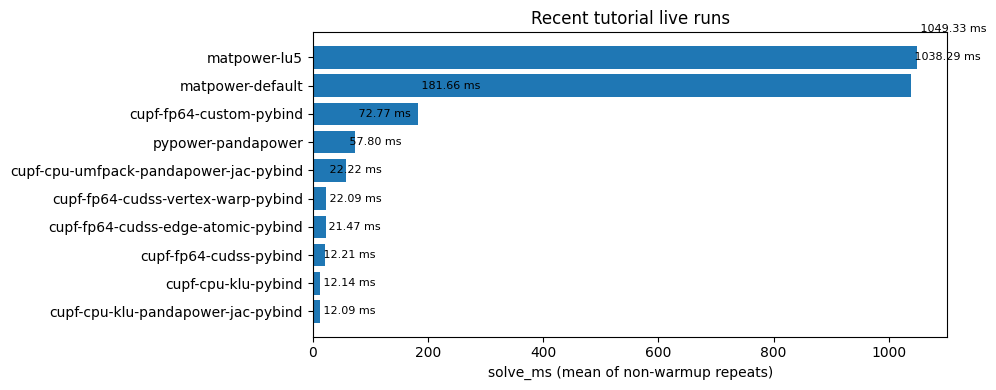

In [2]:
root = tu.tutorial_output_root()
frames = []
for run_json in sorted(root.glob('*/run.json')):
    run_dir = run_json.parent
    runs = tu.load_tutorial_runs(run_dir)
    if not runs.empty:
        summary = tu.summarize_runs(runs)
        summary.insert(0, 'run_name', run_dir.name)
        frames.append(summary)
if frames:
    all_summary = pd.concat(frames, ignore_index=True)
    display(all_summary[['run_name', 'variant', 'linear_solver', 'jacobian', 'initialize_ms', 'solve_ms', 'worst_residual']].tail(30))
    latest = all_summary.dropna(subset=['solve_ms']).tail(20)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(latest))))
    tu.plot_run_solve_bars(latest, ax, 'Recent tutorial live runs')
    plt.tight_layout()
else:
    display(Markdown('아직 `python/tutorial/_runs`에 live result가 없습니다. 앞 노트북을 순서대로 실행하면 이 표가 채워집니다.'))


## Research directions

**cuGraph / graph primitive integration**  
Jacobian fill과 mismatch 계산은 graph traversal와 sparse scatter/gather 성격을 갖습니다. cuGraph 또는 graph-oriented primitive를 적용하면 topology 처리와 edge scheduling을 더 체계적으로 실험할 수 있습니다.

**custom linear solver**  
cuDSS는 강력한 범용 sparse direct solver입니다. 전력계통 Jacobian의 반복 구조, pivoting 특성, batch 반복성을 더 공격적으로 이용하면 custom solver가 이길 여지가 있습니다.

**Multi-GPU**  
단일 대형 case를 나누거나, 많은 scenario batch를 GPU 간에 분산하는 두 방향이 있습니다. 후자는 Monte Carlo, contingency, learning loop와 잘 맞습니다.

**Tensor core / mixed precision**  
Newton step은 정확도가 중요하지만 모든 연산이 FP64일 필요는 없을 수 있습니다. mixed precision은 factorization 안정성, residual correction, iterative refinement와 함께 설계해야 합니다.

**Edge vs Vertex kernels**  
Edge는 병렬성이 좋고, Vertex는 row-local accumulation이 자연스럽습니다. 현재 live 선택지는 `Edge`, `EdgeAtomic`, `VertexWarp`입니다. 효과가 크지 않을 때는 Jacobian kernel보다 sparse solve가 지배적이라는 신호로 해석하는 편이 안전합니다.


In [3]:
future = pd.DataFrame([
    {'topic': 'cuGraph', 'target bottleneck': 'graph traversal, sparse scheduling', 'risk': 'Ybus/Jacobian 특화 구조와 generic graph API 간 overhead'},
    {'topic': 'custom solver', 'target bottleneck': 'factorization/triangular solve', 'risk': 'pivoting 안정성과 다양한 case robustness'},
    {'topic': 'multi-GPU', 'target bottleneck': 'large batch throughput', 'risk': 'partitioning, communication, synchronization'},
    {'topic': 'tensor core', 'target bottleneck': 'dense/small block arithmetic inside sparse solve', 'risk': 'FP64급 정확도와 NR convergence 유지'},
    {'topic': 'mixed precision refinement', 'target bottleneck': 'FP64 solve cost', 'risk': 'ill-conditioned cases에서 residual correction 필요'},
])
display(future)


,topic,target bottleneck,risk
0,cuGraph,"graph traversal, sparse scheduling",Ybus/Jacobian 특화 구조와 generic graph API 간 overhead
1,custom solver,factorization/triangular solve,pivoting 안정성과 다양한 case robustness
2,multi-GPU,large batch throughput,"partitioning, communication, synchronization"
3,tensor core,dense/small block arithmetic inside sparse solve,FP64급 정확도와 NR convergence 유지
4,mixed precision refinement,FP64 solve cost,ill-conditioned cases에서 residual correction 필요
